## Data loading 

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image


In [6]:
DATA_PATH_IMG = "../Chest-X-Ray/image"
DATA_PATH_MSK = "../Chest-X-Ray/mask"

image_paths = sorted(glob(os.path.join(DATA_PATH_IMG, '[0-9]*')))
mask_paths = sorted(glob(os.path.join(DATA_PATH_MSK, '[0-9]*')))

print(f"Total images: {len(image_paths)}")
print(f"Total masks: {len(mask_paths)}")

Total images: 704
Total masks: 704


In [7]:
img = Image.open(image_paths[0]).convert('L')
print("Mode after conversion:", img.mode)

img = img.convert('L')
img = img.resize((256, 256))
print("Resized image size:", img.size)

Mode after conversion: L
Resized image size: (256, 256)


Image mode: L
Image size: (256, 256)


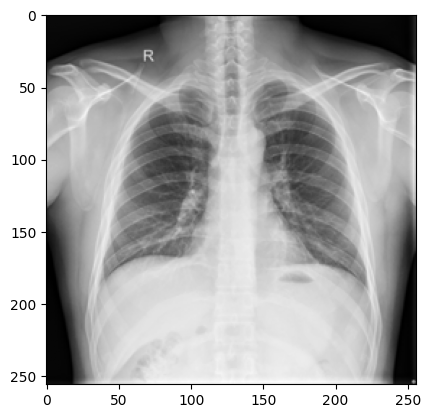

In [8]:
plt.imshow(img, cmap='gray')
print(f"Image mode: {img.mode}")
print(f"Image size: {img.size}")

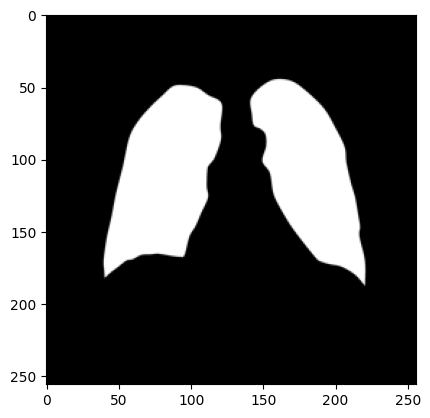

In [9]:
msk = Image.open(mask_paths[0]).convert('L')
msk = msk.resize((256, 256))
plt.imshow(msk, cmap='gray')
plt.show()

### Data Loading Pipeline

In [ ]:
from torch.utils.data import Dataset

class LungSegDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transformations=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transformations = transformations

        print(f"Found {len(self.image_paths)} image-mask pairs")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index])
        mask = Image.open(self.mask_paths[index])

        image = image.convert("L")
        mask = mask.convert("L")

        image = np.array(image)
        mask = np.array(mask)

        mask = (mask > 127).astype(np.float32) # type: ignore

        if self.transformations:
            transformed = self.transformations(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        return image, mask
        

In [13]:
dataset = LungSegDataset(image_paths, mask_paths)
image, mask = dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image min/max:", image.min(), image.max())
print("Mask unique values:", np.unique(mask))

Found 704 image-mask pairs
Image shape: (256, 256)
Mask shape: (256, 256)
Image min/max: 0 248
Mask unique values: [0. 1.]


In [14]:
from sklearn.model_selection import train_test_split

# First split: 85% train+val, 15% test
train_val_imgs, test_imgs, train_val_msks, test_msks = train_test_split(
    image_paths, mask_paths, test_size=0.15, random_state=42
)

# Second split: 70% train, 15% val (from the 85%)
train_imgs, val_imgs, train_msks, val_msks = train_test_split(
    train_val_imgs, train_val_msks, test_size=0.176, random_state=42
)

In [15]:
print(f"Train: {len(train_imgs)}")
print(f"Val: {len(val_imgs)}")
print(f"Test: {len(test_imgs)}")

Train: 492
Val: 106
Test: 106


In [16]:
train_dataset = LungSegDataset(train_imgs, train_msks)
val_dataset = LungSegDataset(val_imgs, val_msks)
test_dataset = LungSegDataset(test_imgs, test_msks)

Found 492 image-mask pairs
Found 106 image-mask pairs
Found 106 image-mask pairs


In [18]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Data augmentation transforms
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [19]:
train_dataset = LungSegDataset(train_imgs, train_msks, transformations=train_transform)
val_dataset = LungSegDataset(val_imgs, val_msks, transformations=val_transform)
test_dataset = LungSegDataset(test_imgs, test_msks, transformations=val_transform)

Found 492 image-mask pairs
Found 106 image-mask pairs
Found 106 image-mask pairs


In [20]:
image, mask = train_dataset[0]
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image min/max:", image.min(), image.max())
print("Mask unique values:", mask.unique())

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([256, 256])
Image min/max: tensor(-1.) tensor(1.)
Mask unique values: tensor([0., 1.])


### Testing Pipeline

In [21]:
import sys
sys.path.append('../src')

from dataset import split_datasets

train_dataset, val_dataset, test_dataset = split_datasets(image_paths, mask_paths)

# Sanity check
image, mask = train_dataset[0]
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image min/max:", image.min(), image.max())
print("Mask unique values:", mask.unique())

Found 492 image-mask pairs
Found 106 image-mask pairs
Found 106 image-mask pairs
Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([256, 256])
Image min/max: tensor(-1.) tensor(1.)
Mask unique values: tensor([0., 1.])
